# 5. What the network actually used

Two views of one question, run against a saved fold checkpoint, so the model being examined is the
one that produced the reported score for that fold on tapes it never saw.

Occlusion measures what the model loses when a band of frequencies disappears. Grad-CAM shows where
the last convolutional stage responded. The first is a cost the model has to pay, the second is a
lead worth following, and they are reported together because either one alone is easy to over-read.

Run `python -m src.evaluate.explain --config configs/base.yaml --name cnn_small --fold 3` first. The
figures below are read from disk, since regenerating them needs the feature cache and a checkpoint,
and neither is committed.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src.config import load_config
from src.evaluate import families
from src.results import config_directory, model_directory

cfg = load_config("configs/base.yaml")
REPORT = config_directory(cfg)
pd.set_option("display.width", 180)

# Named rather than discovered. Picking the first directory that happens to hold an
# occlusion.csv used to land on the call type network, because it sorts first, and
# nothing raised: the table came from one model and the figure beside it from another.
SPECIES_MODEL = "cnn_small"
CALL_TYPE_MODEL = "calltype_spermwhale_coda_cnn_small"

for name in (SPECIES_MODEL, CALL_TYPE_MODEL):
    classes = families.class_names_of(cfg, name)
    print(f"{name}: {', '.join(classes)}")

cnn_small: HumpbackWhale, SpermWhale, KillerWhale
calltype_spermwhale_coda_cnn_small: absent, present


## 1. What each frequency band is worth

Each row masks one contiguous group of mel bands on held out windows and rescores. A band the model
genuinely relies on shows a positive drop. A negative drop means the model did slightly better
without that band, which is noise rather than evidence of anything.

One caveat that governs how hard to read this table: it comes from a single fold, not from the fifty
splits behind every score in notebook 02. It has no interval and no test attached.

In [2]:
occlusion = pd.read_csv(model_directory(cfg, SPECIES_MODEL) / "occlusion.csv")
print(
    f"fold {occlusion.fold.unique().tolist()}, {len(occlusion)} bands from "
    f"{occlusion.band_low_hz.min():.0f} to {occlusion.band_high_hz.max():.0f} Hz"
)

columns = ["band_low_hz", "band_high_hz", "macro_f1", "macro_f1_drop"]
columns += [c for c in occlusion.columns if c.startswith("recall_") and c.endswith("_drop")]
occlusion[columns].round(3)

fold [3], 8 bands from 50 to 4900 Hz


,band_low_hz,band_high_hz,macro_f1,macro_f1_drop,recall_HumpbackWhale_drop,recall_SpermWhale_drop,recall_KillerWhale_drop
0,50.000,326.782,0.831,0.068,0.118,0.049,0.019
1,366.322,643.104,0.865,0.034,0.074,0.039,-0.002
2,682.644,959.426,0.905,-0.006,0.000,0.015,-0.004
3,998.966,1328.928,0.910,-0.011,0.000,0.000,0.004
4,1384.238,1841.515,0.883,0.016,0.000,0.005,0.025
5,1918.158,2551.813,0.896,0.003,-0.015,0.010,0.006
6,2658.018,3536.083,0.883,0.017,-0.015,0.000,0.029
7,3683.254,4900.000,0.872,0.028,-0.015,-0.005,0.052


Read the per species columns against the calls each animal is known to make. Humpback song is
low and tonal, killer whale whistles are high, sperm whale clicks are broadband and so should not
depend on any single band.

HumpbackWhale  loses most at 50 Hz (+0.118), least at 1918 Hz (-0.015)
SpermWhale     loses most at 50 Hz (+0.049), least at 3683 Hz (-0.005)
KillerWhale    loses most at 3683 Hz (+0.052), least at 683 Hz (-0.004)


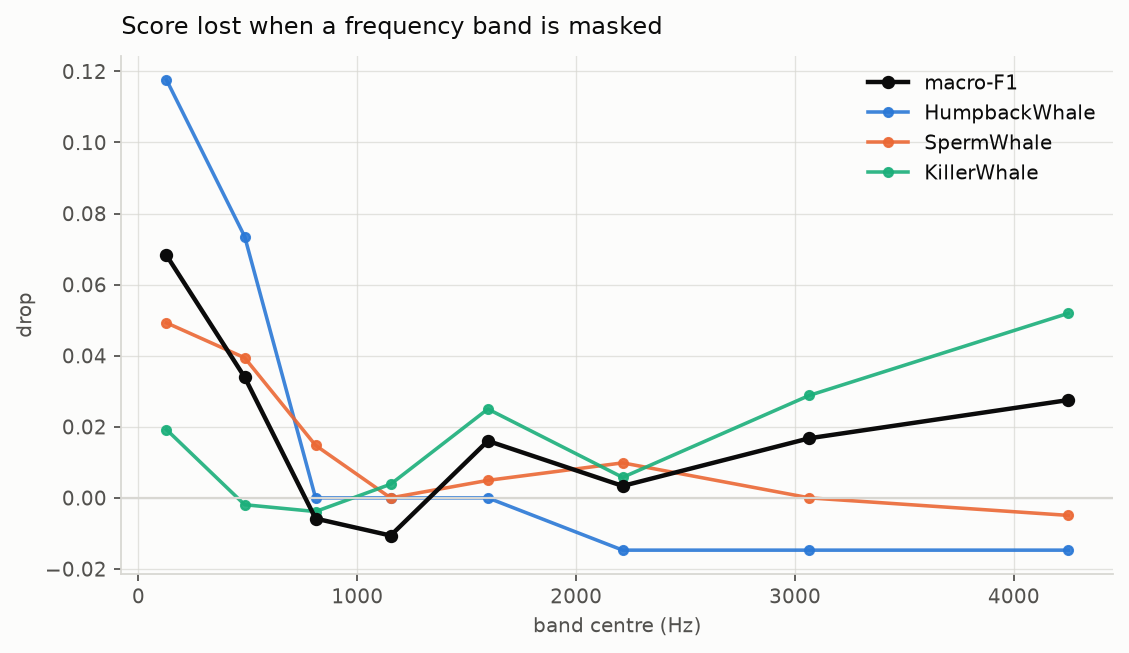

In [3]:
drops = occlusion.set_index("band_low_hz")[
    [c for c in occlusion.columns if c.endswith("_drop") and c.startswith("recall_")]
]
for column in drops.columns:
    species = column.removeprefix("recall_").removesuffix("_drop")
    worst = drops[column].idxmax()
    print(
        f"{species:14s} loses most at {worst:.0f} Hz ({drops[column].max():+.3f}), "
        f"least at {drops[column].idxmin():.0f} Hz ({drops[column].min():+.3f})"
    )

display(Image(filename=str(model_directory(cfg, SPECIES_MODEL) / "occlusion.png")))

## 2. Where the last convolutional stage responded

Sampled from correctly classified held out windows, so the maps show evidence the model acted on
rather than a failure case. The peak frequency of each map is the row of the heat map carrying most
of its weight.

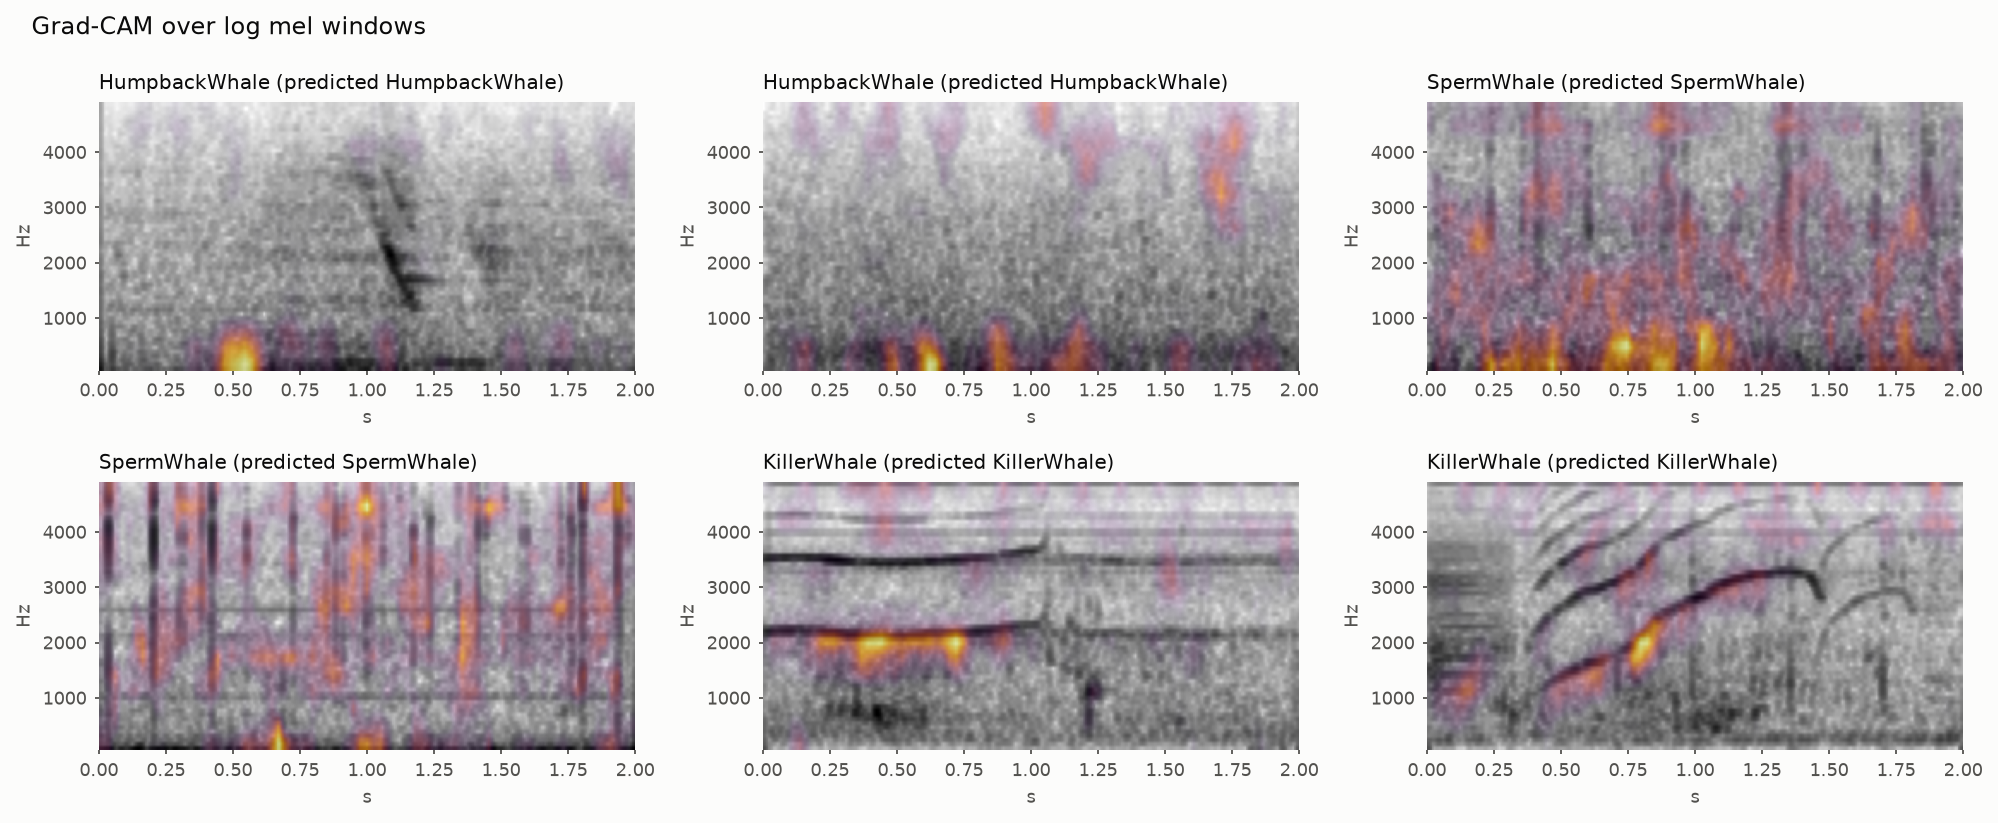

,example,peak_frequency_hz
0,HumpbackWhale (predicted HumpbackWhale),247.7
1,HumpbackWhale (predicted HumpbackWhale),50.0
2,SpermWhale (predicted SpermWhale),50.0
3,SpermWhale (predicted SpermWhale),3836.5
4,KillerWhale (predicted KillerWhale),1040.5
5,KillerWhale (predicted KillerWhale),4704.2


In [4]:
display(Image(filename=str(model_directory(cfg, SPECIES_MODEL) / "gradcam.png")))
pd.read_csv(model_directory(cfg, SPECIES_MODEL) / "gradcam_peaks.csv").round(1)

Grad-CAM lands in similar places to occlusion for humpback, which is the agreement worth having: two
methods with different failure modes pointing at the same band.

It agrees less well for killer whale, where the peaks straddle the whistle band rather than sitting
in it. Two peaks also sit at the very bottom of the mel grid, which is the edge of the analysis
range and is as likely to be an artefact of the layout as a finding.

## 3. The same two views on a call type model

Notebook 04 posed call type questions inside one species. One of them was fitted with the same
network, so the same two views apply, and the classes are now `absent` and `present` rather than
three species.

This is the model that has to distinguish a coda from anything else a sperm whale does, so a
dependence on the broadband range would be consistent with clicks.

In [5]:
coda = pd.read_csv(model_directory(cfg, CALL_TYPE_MODEL) / "occlusion.csv")
print("classes:", ", ".join(families.class_names_of(cfg, CALL_TYPE_MODEL)))

columns = ["band_low_hz", "band_high_hz", "macro_f1", "macro_f1_drop"]
columns += [c for c in coda.columns if c.startswith("recall_") and c.endswith("_drop")]
display(coda[columns].round(3))

worst = coda.loc[coda.macro_f1_drop.idxmax()]
print(
    f"most costly band: {worst.band_low_hz:.0f} to {worst.band_high_hz:.0f} Hz, "
    f"macro-F1 drop {worst.macro_f1_drop:+.3f}"
)

classes: absent, present


,band_low_hz,band_high_hz,macro_f1,macro_f1_drop,recall_absent_drop,recall_present_drop
0,50.000,326.782,0.662,-0.016,-0.097,0.143
1,366.322,643.104,0.639,0.007,-0.044,0.095
2,682.644,959.426,0.625,0.022,-0.027,0.095
3,998.966,1328.928,0.640,0.006,-0.018,0.048
4,1384.238,1841.515,0.639,0.007,-0.044,0.095
5,1918.158,2551.813,0.608,0.038,-0.035,0.143
6,2658.018,3536.083,0.583,0.064,-0.035,0.190
7,3683.254,4900.000,0.554,0.093,0.106,0.048


most costly band: 3683 to 4900 Hz, macro-F1 drop +0.093


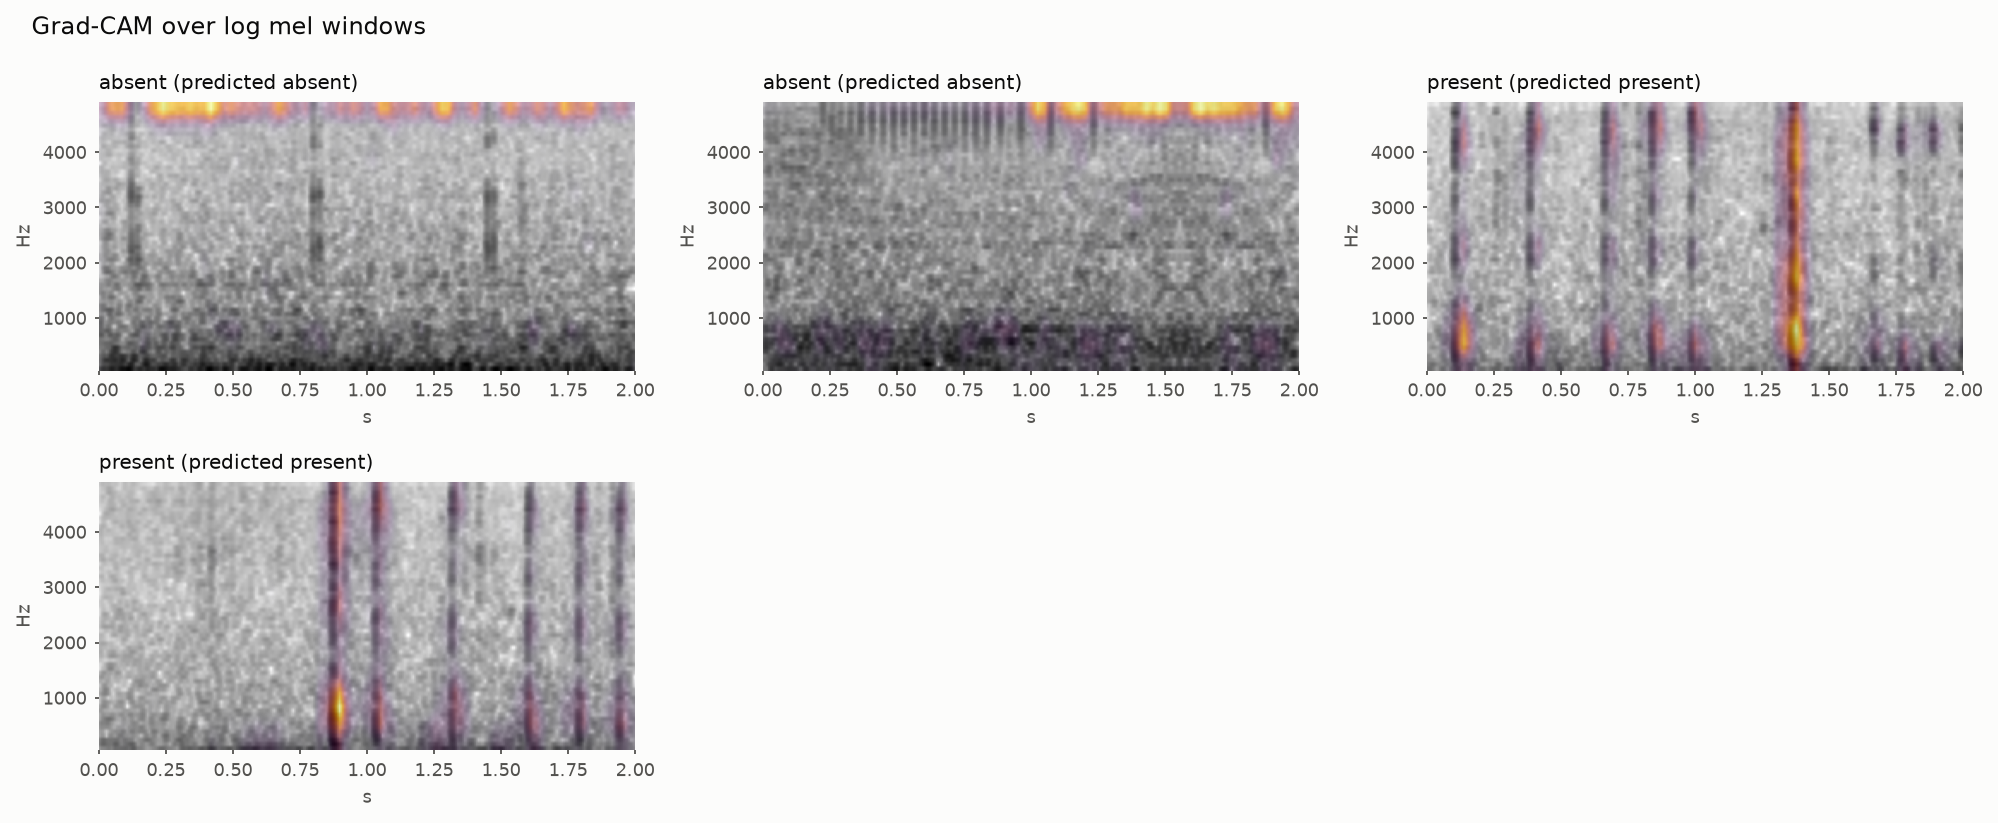

In [6]:
display(Image(filename=str(model_directory(cfg, CALL_TYPE_MODEL) / "gradcam.png")))

## 4. What the tree models leaned on

The trees report which features carried the fit, which the networks cannot. Two different things are
shown below and they must not be read the same way.

`xgboost` is given the audio, as hand engineered acoustic descriptors. Its gains say which
descriptors of the sound mattered.

In [7]:
importance = pd.read_csv(model_directory(cfg, "xgboost") / "feature_importance.csv")
share = importance.groupby("feature").gain.mean().sort_values(ascending=False)
(share / share.sum()).head(8).round(3).to_frame("share of gain")

,share of gain
feature,
mfcc_16_std,0.075
contrast_2_std,0.044
mfcc_1_p10,0.038
contrast_0_p10,0.025
contrast_4_mean,0.023
mfcc_15_std,0.022
dominant_frequency,0.019
flatness_p90,0.019


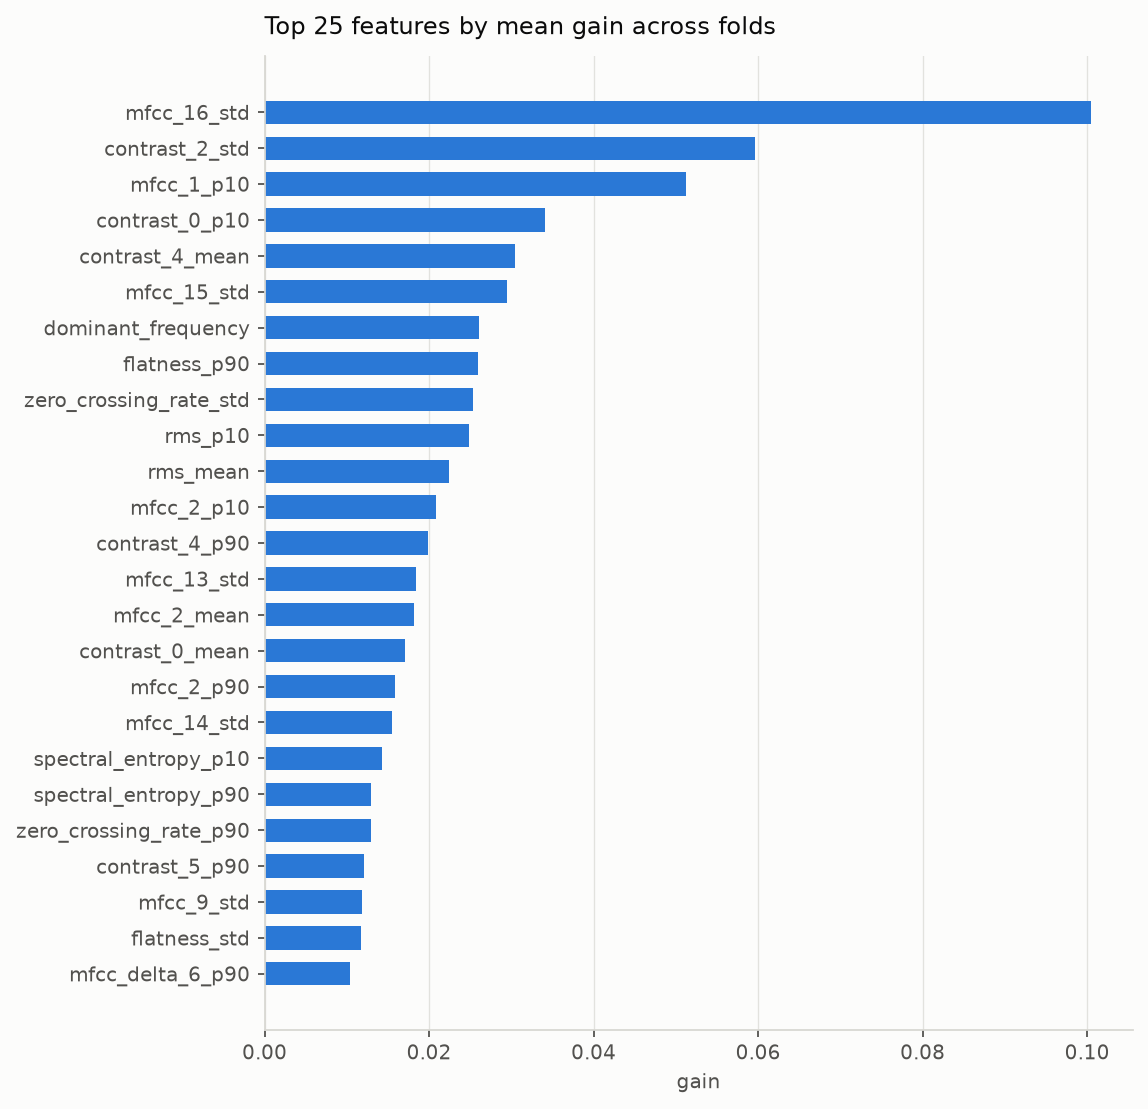

In [8]:
display(Image(filename=str(REPORT / "feature_importance_xgboost.png")))

## 5. What the models with no audio leaned on

`logbook` and `metadata` are given no sound at all, so nothing below is a descriptor of anything
audible. These are the fields from notebook 01, and this is where the project's headline confound
appears as a number rather than as an argument.

`collection_code` here is the four characters at the front of a field note.

In [9]:
for name in ("logbook", "metadata"):
    importance = pd.read_csv(model_directory(cfg, name) / "feature_importance.csv")
    share = importance.groupby("feature").gain.mean().sort_values(ascending=False)
    print(f"{name}, share of gain:")
    print((share / share.sum()).head(5).round(3).to_string())
    print()

logbook, share of gain:
feature
native_sample_rate    0.458
latitude              0.350
collection_code       0.113
bytes_on_disk         0.049
site_code             0.016

metadata, share of gain:
feature
native_sample_rate    0.579
year                  0.213
duration_seconds      0.106
bytes_on_disk         0.101



logbook


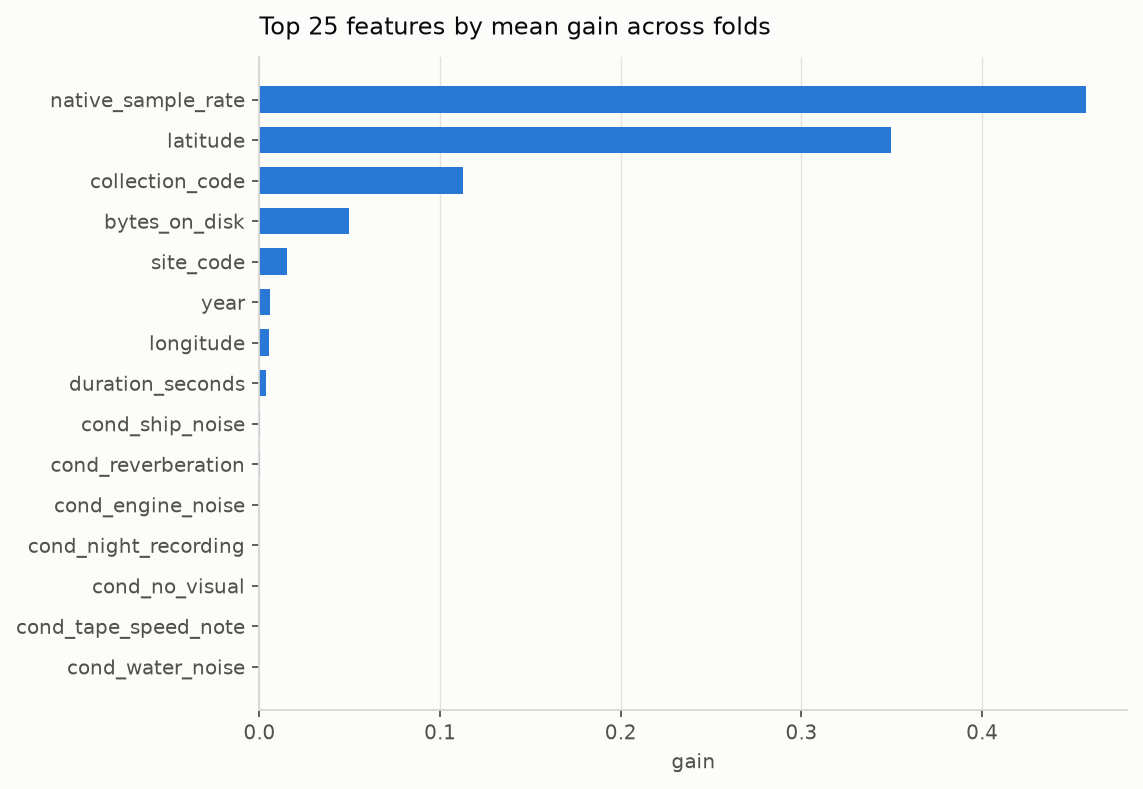

metadata


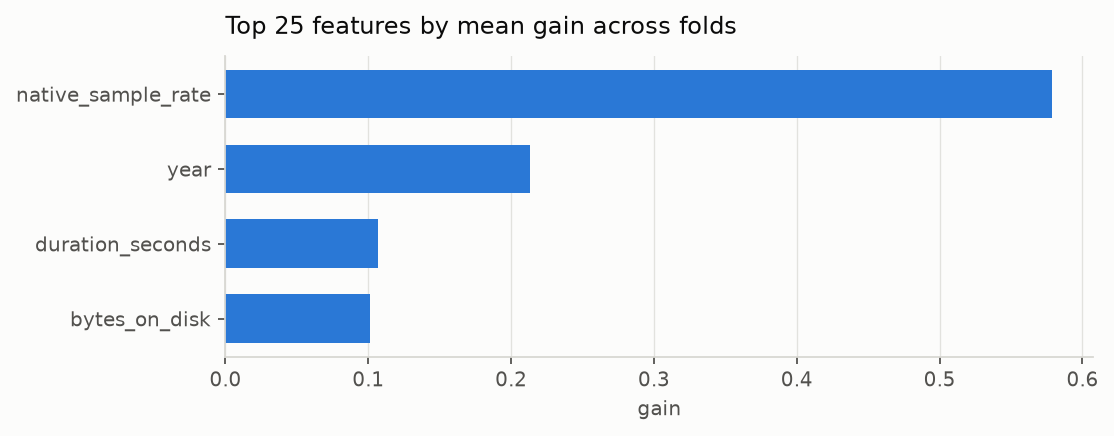

In [10]:
for name in ("logbook", "metadata"):
    path = REPORT / f"feature_importance_{name}.png"
    if path.exists():
        print(name)
        display(Image(filename=str(path)))

## What this notebook does not settle

Everything above comes from one fold of one split, fitted with one seed. None of it carries an
interval or a test, unlike every number in notebooks 02 to 04. Treat a band that costs 0.02 macro-F1
as indistinguishable from one that costs nothing.

Grad-CAM on three classes over 134 recordings is suggestive rather than evidence. It shows where a
particular network responded on a handful of windows it happened to classify correctly, and a
different seed would sample different windows.

The agreement between the two methods for humpback is the strongest thing here, because they fail in
different ways and still point at the same band. The disagreement for killer whale is worth as much
attention, and it is not resolved by anything in this repository.